In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
import numpy as np
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten
import os
import cv2

In [3]:
x,y=[],[]
path=r"C:\Users\GOURI BIJU\Desktop\Gouripython\Lung Cancer\train"
for i in os.listdir(path):
    for j in os.listdir(os.path.join(path,i)):
        image_path=os.path.join(path,i,j)
        array=cv2.imread(image_path)
        array_resize=cv2.resize(array,(110,110))
        array_reshape=array_resize.reshape(110,110,3)
        array_norm=array_reshape/255
        x.append(array_norm)
        y.append(i)
x=np.array(x)
y=np.array(y)
print(x.shape)
print(y.shape)

(613, 110, 110, 3)
(613,)


In [4]:
y

array(['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
       'adenocarcinoma_left.lower.lobe_T2_N0_M

In [5]:
le=LabelEncoder()

In [6]:
y=le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [7]:
y.shape

(613,)

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=48)

In [9]:
print(len(xtrain),len(ytrain))
print(len(xtest),len(ytest))

490 490
123 123


In [10]:
print(xtest.shape)

(123, 110, 110, 3)


In [11]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(110,110,3)))
model.add(MaxPool2D(2,2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(4,activation='softmax'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 108, 108, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,188 (9.36 MB)

 Trainable params: 2,453,188 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [72]:
model.fit(xtrain,ytrain,batch_size=64,epochs=15,validation_data=(xtest,ytest))

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.9625 - loss: 0.0962 - val_accuracy: 0.9024 - val_loss: 0.4537
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.9833 - loss: 0.0650 - val_accuracy: 0.8780 - val_loss: 0.5046
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.9927 - loss: 0.0660 - val_accuracy: 0.8780 - val_loss: 0.4742
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.9995 - loss: 0.0234 - val_accuracy: 0.8862 - val_loss: 0.4947
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.9995 - loss: 0.0177 - val_accuracy: 0.8780 - val_loss: 0.5504
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.9937 - loss: 0.0361 - val_accuracy: 0.8374 - val_loss: 0.5742
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.9905 - loss: 0.0470 - val_accuracy: 0.8943 - val_loss: 0.5916
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9975 - loss: 0.0242 - val_accuracy: 0.8780 - val_loss:

In [15]:
test_path=r"C:\Users\GOURI BIJU\Desktop\Gouripython\Lung Cancer\valid\adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib\000115 (9).png"
array=cv2.imread(test_path)
array_resize=cv2.resize(array,(110,110))
array_reshape=array_resize.reshape(1,110,110,3)
array_norm=array_reshape/255
print(array_norm.shape)

(1, 110, 110, 3)


In [16]:
a=model.predict(array_norm)
a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


array([[0.7824436 , 0.03811515, 0.00180903, 0.17763221]], dtype=float32)

In [17]:
a=np.argmax(a)
a

0

In [18]:
l=['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
l[a]

'Adenocarcinoma'

In [19]:
test_path=r"C:\Users\GOURI BIJU\Desktop\Gouripython\Lung Cancer\valid\large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa\000128.png"
array=cv2.imread(test_path)
array_resize=cv2.resize(array,(110,110))
array_reshape=array_resize.reshape(1,110,110,3)
array_norm=array_reshape/255
print(array_norm.shape)

(1, 110, 110, 3)


In [20]:
a=model.predict(array_norm)
a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[5.6240993e-04, 9.9540305e-01, 8.1054429e-07, 4.0337453e-03]],
      dtype=float32)

In [21]:
a=np.argmax(a)
a

1

In [22]:
l=['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
l[a]

'Large Cell Carcinoma'

In [23]:
test_path=r"C:\Users\GOURI BIJU\Desktop\Gouripython\Lung Cancer\valid\normal\7.png"
array=cv2.imread(test_path)
array_resize=cv2.resize(array,(110,110))
array_reshape=array_resize.reshape(1,110,110,3)
array_norm=array_reshape/255
print(array_norm.shape)

(1, 110, 110, 3)


In [24]:
a=model.predict(array_norm)
a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[7.5778761e-10, 6.8671259e-05, 9.9993134e-01, 4.4764636e-10]],
      dtype=float32)

In [25]:
a=np.argmax(a)
a

2

In [26]:
l=['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
l[a]

'Normal'

In [27]:
test_path=r"C:\Users\GOURI BIJU\Desktop\Gouripython\Lung Cancer\valid\squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa\000111.png"
array=cv2.imread(test_path)
array_resize=cv2.resize(array,(110,110))
array_reshape=array_resize.reshape(1,110,110,3)
array_norm=array_reshape/255
print(array_norm.shape)

(1, 110, 110, 3)


In [28]:
a=model.predict(array_norm)
a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.6177054e-02, 2.3661965e-01, 4.1001613e-04, 7.4679327e-01]],
      dtype=float32)

In [29]:
a=np.argmax(a)
a

3

In [30]:
l=['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
l[a]

'Squamous Cell Carcinoma'

In [31]:
print(model.input_shape)

(None, 110, 110, 3)


In [32]:
ypred = model.predict(xtest)
ypred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[9.16904092e-01, 6.87175840e-02, 6.28792122e-07, 1.43776387e-02],
       [2.80118058e-03, 1.76474750e-05, 1.36325170e-05, 9.97167647e-01],
       [2.74906070e-05, 9.98316169e-01, 1.65479968e-03, 1.51984057e-06],
       [9.67457116e-01, 4.92041558e-03, 8.03942658e-06, 2.76143458e-02],
       [5.50273061e-03, 2.06889510e-02, 2.60708330e-05, 9.73782241e-01],
       [1.07041188e-03, 9.98871386e-01, 1.32763898e-06, 5.67403295e-05],
       [2.51087622e-04, 2.45487638e-04, 3.59852493e-05, 9.99467552e-01],
       [9.99021769e-01, 2.64929531e-05, 1.02950696e-06, 9.50677961e-04],
       [2.21753051e-08, 1.00000000e+00, 6.56788124e-10, 6.96928903e-11],
       [2.71727032e-08, 4.51967388e-08, 1.00000000e+00, 1.35345846e-09],
       [7.32344508e-01, 1.31154256e-02, 5.15155634e-03, 2.49388531e-01],
       [7.90011223e-10, 1.00989361e-07, 9.99999046e-01, 8.72832743e-07],
       [9.73633468e-01, 2.49502454e-02, 2.82040924e-06, 1.41349004e-03],
       [1.61437094e-02, 2.22704781e-04, 7.46871274e

In [33]:
al=[]
for i in ypred:
#     print(i)
    al.append(np.argmax(i))
print(al)

[0, 3, 1, 0, 3, 1, 3, 0, 1, 2, 0, 2, 0, 3, 2, 0, 1, 3, 1, 3, 3, 3, 0, 3, 3, 0, 2, 2, 1, 1, 3, 0, 3, 3, 1, 0, 0, 3, 2, 2, 0, 1, 0, 2, 0, 2, 3, 3, 2, 3, 3, 2, 3, 3, 0, 3, 3, 3, 0, 0, 1, 2, 1, 1, 2, 2, 3, 0, 1, 0, 3, 0, 3, 0, 2, 3, 3, 0, 3, 3, 2, 3, 2, 0, 1, 1, 0, 1, 0, 0, 2, 1, 1, 0, 3, 3, 0, 1, 2, 3, 2, 1, 2, 0, 2, 2, 0, 3, 3, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 3, 1, 0, 1]


In [34]:
cm=confusion_matrix(ytest,al)
cm

array([[37,  2,  2,  5],
       [ 0, 19,  0,  1],
       [ 0,  0, 24,  0],
       [ 0,  1,  1, 31]], dtype=int64)

<Axes: >

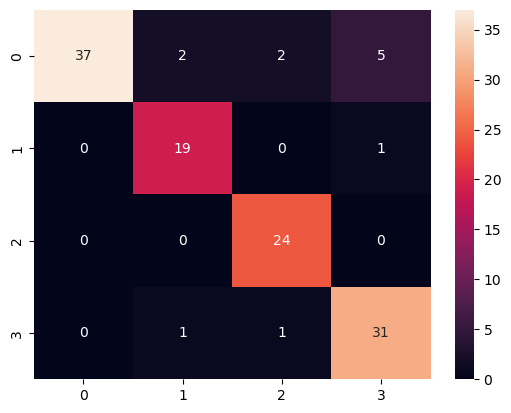

In [35]:
sns.heatmap(cm,annot=True,fmt='d')